In [21]:
# !pip install torch torchvision albumentations pandas scikit-learn pillow matplotlib tqdm seaborn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

/Users/nadiaroschina/Library/Mobile Documents/com~apple~CloudDocs/masters_icloud/PROJECT/teeth_classes_classification/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
torch.cuda.is_available()

False

In [4]:
torch.__version__

'2.11.0'

In [5]:
from utils_2_dataloader import ToothDataset, load_and_prepare_data, get_transforms, create_dataloaders, \
    TOOTH_ID_TO_CLASS_NAME, IDX_TO_CLASS_NAME, CLASS_MAPPING_RULES, DATA_DIR, JSON_PATH, CLASS_NAMES

In [6]:
# --- ФУНКЦИИ ОБУЧЕНИЯ И ВАЛИДАЦИИ ---

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        
    epoch_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return epoch_loss, accuracy, f1

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validating")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    epoch_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return epoch_loss, accuracy, f1, all_preds, all_labels

In [7]:
# --- СОЗДАНИЕ МОДЕЛИ ---

def get_model(model_name: str, num_classes: int, pretrained: bool = True):
    """
    Создает модель, загружает веса и заменяет голову.
    Замораживает backbone.
    """
    if model_name == "efficientnet-b0":
        from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
        
        if pretrained:
            weights = EfficientNet_B0_Weights.IMAGENET1K_V1
            model = efficientnet_b0(weights=weights)
        else:
            model = efficientnet_b0()
            
        # Получаем количество входных фич последнего слоя перед классификатором
        in_features = model.classifier[1].in_features
        
        # Заменяем голову на новый линейный слой
        # classifier в EfficientNet это Sequential(Dropout, Linear)
        model.classifier[1] = nn.Linear(in_features, num_classes)
        
    elif model_name == "resnet18":
        from torchvision.models import resnet18, ResNet18_Weights
        if pretrained:
            weights = ResNet18_Weights.IMAGENET1K_V1
            model = resnet18(weights=weights)
        else:
            model = resnet18()
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    else:
        raise ValueError(f"Model {model_name} not supported in this snippet")

    # ЗАМОРАЖИВАЕМ ВСЕ ПАРАМЕТРЫ БЭКБОНА
    for param in model.parameters():
        param.requires_grad = False
        
    # Размораживаем только параметры новой головы (они уже требуют градиента по умолчанию при создании, 
    # но проверим явно для головы)
    # В случае EfficientNet голова - это model.classifier[1]
    if model_name == "efficientnet-b0":
        for param in model.classifier[1].parameters():
            param.requires_grad = True
    elif model_name == "resnet18":
        for param in model.fc.parameters():
            param.requires_grad = True
            
    return model.to(DEVICE)

In [8]:
# --- КОНФИГУРАЦИЯ ОБУЧЕНИЯ ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "efficientnet-b0"
NUM_CLASSES = len(CLASS_NAMES)
BATCH_SIZE = 32
EPOCHS = 10  # Для базового теста 10 эпох достаточно, так как учим только голову
LEARNING_RATE = 1e-3
IMG_SIZE = 224
print(f"Using device: {DEVICE}")

Using device: cpu


In [9]:
# 1. Подготовка данных
print("Loading DataLoaders...")
train_loader, val_loader, test_loader = create_dataloaders(
    batch_size=BATCH_SIZE, 
    num_workers=4, 
    
)

Loading DataLoaders...
Total valid samples loaded: 6069
Split sizes -> Train: 4247, Val: 911, Test: 911
Train: 4247, Val: 911, Test: 911


/Users/nadiaroschina/Library/Mobile Documents/com~apple~CloudDocs/masters_icloud/PROJECT/teeth_classes_classification/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [10]:
# 2. Создание модели
print(f"Initializing Model: {MODEL_NAME} (Frozen Backbone)...")
model = get_model(MODEL_NAME, NUM_CLASSES, pretrained=True)

Initializing Model: efficientnet-b0 (Frozen Backbone)...


In [11]:
# Критерий и Оптимизатор
# Используем CrossEntropyLoss (стандарт для классификации)
criterion = nn.CrossEntropyLoss()
# Оптимизируем ТОЛЬКО параметры, требующие градиента (наша голова)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [12]:

print("\nStarting Training (Baseline v0)...\n")


best_val_f1 = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}


for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    
    # Train
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    
    # Validate
    val_loss, val_acc, val_f1, _, _ = validate_epoch(model, val_loader, criterion, DEVICE)
    
    # Step scheduler
    scheduler.step(val_loss)
    
    # Log
    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
    print("-" * 30)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_baseline_v0.pth")
        print(f"New best model saved with Val F1: {best_val_f1:.4f}")


Starting Training (Baseline v0)...

Epoch 1/10


Validating: 100%|██████████| 29/29 [01:12<00:00,  2.48s/it]


Train Loss: 0.8394, Acc: 0.6202, F1: 0.5962
Val   Loss: 0.6125, Acc: 0.7552, F1: 0.7564
------------------------------
New best model saved with Val F1: 0.7564
Epoch 2/10


Validating: 100%|██████████| 29/29 [01:17<00:00,  2.66s/it]


Train Loss: 0.7084, Acc: 0.6883, F1: 0.6815
Val   Loss: 0.5364, Acc: 0.7717, F1: 0.7718
------------------------------
New best model saved with Val F1: 0.7718
Epoch 3/10


...

Train Loss: 0.6136, Acc: 0.7306, F1: 0.7275
Val   Loss: 0.4494, Acc: 0.8200, F1: 0.8167
------------------------------
New best model saved with Val F1: 0.8167
Epoch 9/10


Validating: 100%|██████████| 29/29 [01:10<00:00,  2.41s/it]


Train Loss: 0.6003, Acc: 0.7283, F1: 0.7251
Val   Loss: 0.4440, Acc: 0.8255, F1: 0.8258
------------------------------
New best model saved with Val F1: 0.8258
Epoch 10/10


Validating: 100%|██████████| 29/29 [01:09<00:00,  2.40s/it]


Train Loss: 0.6053, Acc: 0.7304, F1: 0.7273
Val   Loss: 0.4267, Acc: 0.8244, F1: 0.8236
------------------------------


In [13]:
# --- ФИНАЛЬНЫЙ ТЕСТ ---
print("\nRunning Final Evaluation on Test Set...")
model.load_state_dict(torch.load("best_baseline_v0.pth"))
test_loss, test_acc, test_f1, y_pred, y_true = validate_epoch(model, test_loader, criterion, DEVICE)

print(f"\n=== FINAL RESULTS (Test Set) ===")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Score (weighted): {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Running Final Evaluation on Test Set...


Validating: 100%|██████████| 29/29 [01:09<00:00,  2.41s/it]



=== FINAL RESULTS (Test Set) ===
Accuracy: 0.8573
F1 Score (weighted): 0.8567

Classification Report:
              precision    recall  f1-score   support

     incisor       0.85      0.80      0.83       325
      canine       0.77      0.79      0.78        82
    premolar       0.79      1.00      0.88        15
       molar       0.88      0.90      0.89       489

    accuracy                           0.86       911
   macro avg       0.82      0.87      0.84       911
weighted avg       0.86      0.86      0.86       911



Training history plot saved as 'training_history_v0.png'


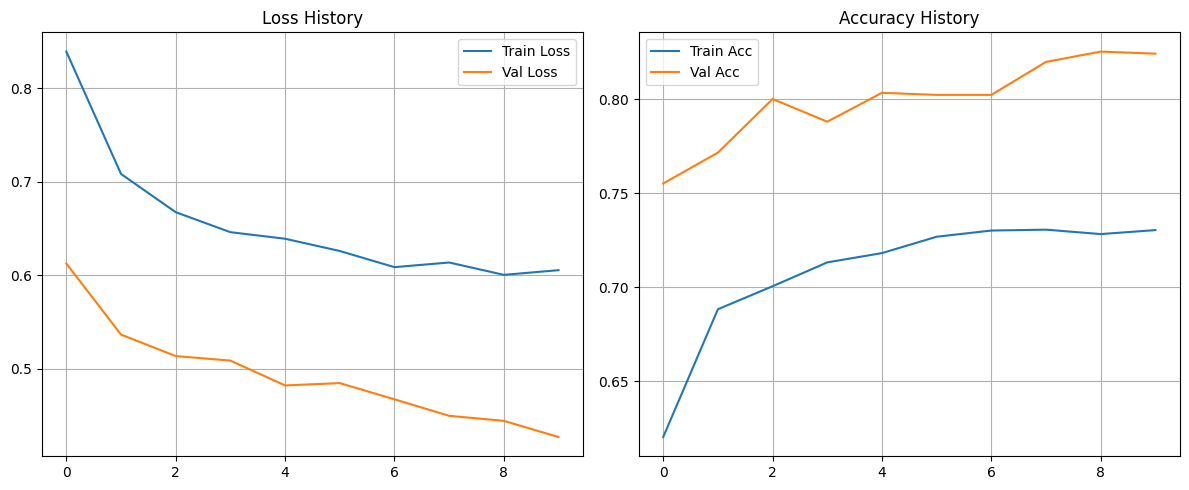

In [14]:
# Построение графиков
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy History')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_history_v0.png")
print("Training history plot saved as 'training_history_v0.png'")

In [23]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

Gathering predictions on Test Set...


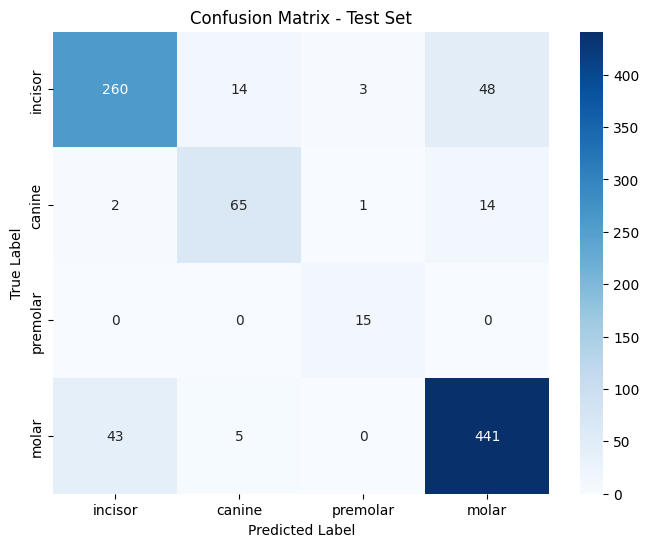


--- Correct Predictions (High Confidence) ---


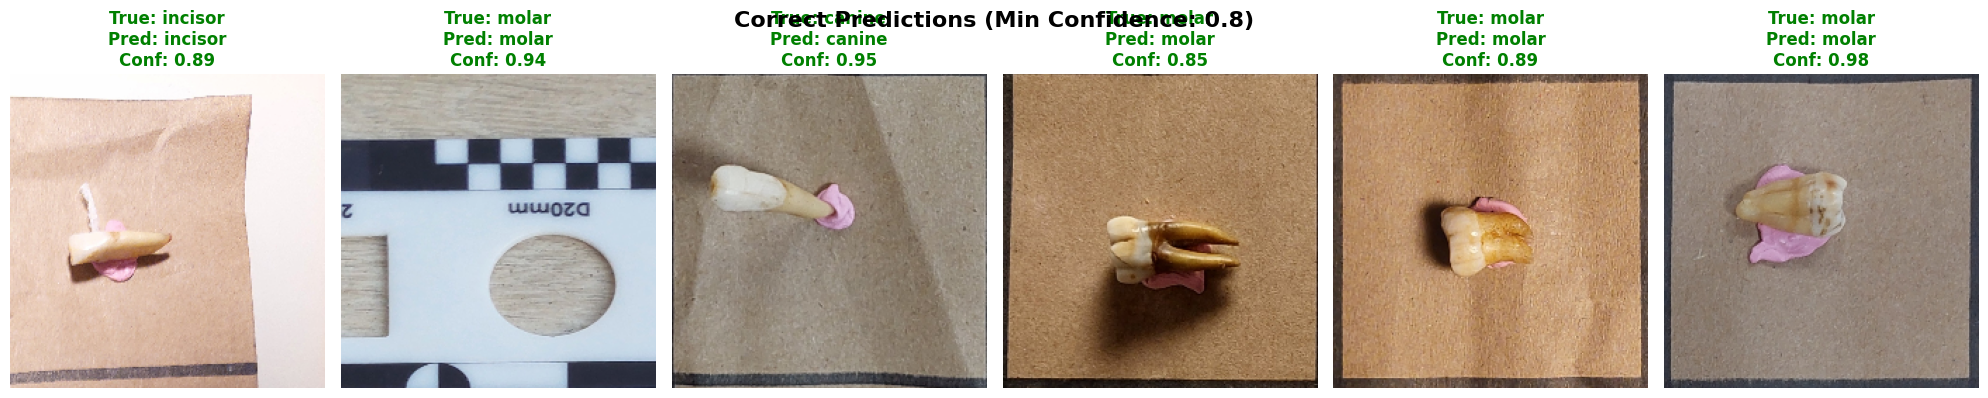


--- Mistakes (All errors) ---


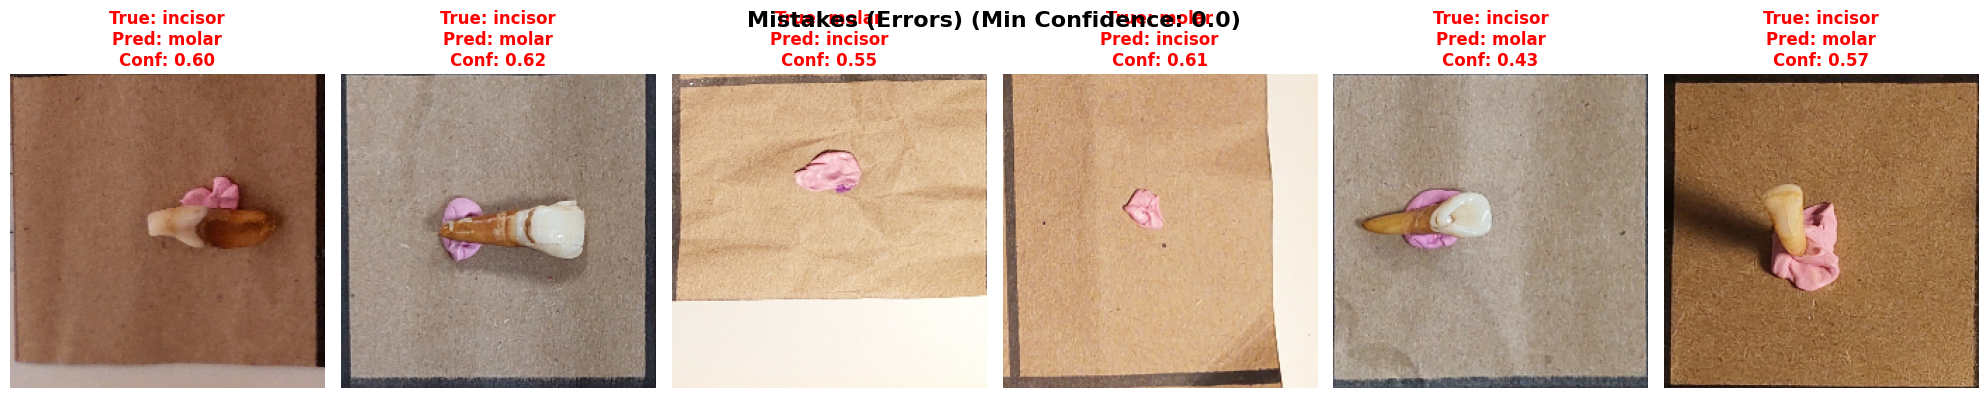


--- Mistakes with High Confidence (>0.7) ---


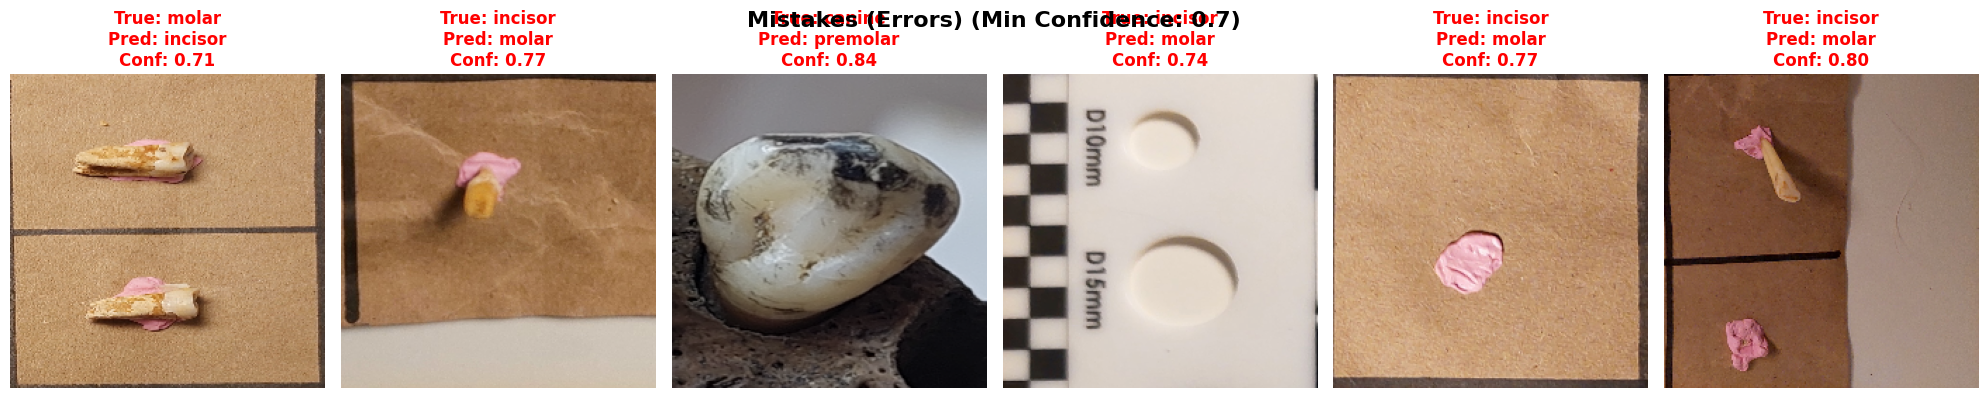

In [24]:
# --- НАСТРОЙКИ ---
# Убедитесь, что переменные из предыдущих ячеек доступны:
# model, test_loader, DEVICE, CLASS_NAMES, IDX_TO_CLASS_NAME
# Если модель сохранена на диск, раскомментируйте строку загрузки ниже:
# model.load_state_dict(torch.load("best_baseline_v0.pth")) 

model.eval()
device = DEVICE

# Сбор всех предсказаний, истинных меток, путей к файлам и вероятностей
all_preds = []
all_labels = []
all_probs = []
all_images = []
all_file_names = [] # Если ваш Dataset возвращает имена файлов, иначе пропускаем

# Примечание: В нашем классе ToothDataset мы не возвращали имя файла в __getitem__.
# Чтобы получить имена, нам нужно немного хитрости или доступ к исходным спискам.
# Для простоты в этом блоке мы будем использовать индексы из test_loader.dataset, 
# но так как DataLoader перемешивает данные, нам нужно восстановить пути.
# Давайте пройдемся по датасету напрямую для получения путей, если нужно, 
# но проще всего просто собрать батчи и отобразить картинки.

print("Gathering predictions on Test Set...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_images.append(images.cpu()) # Сохраняем тензоры картинок

# Конвертация списков
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_images = torch.cat(all_images, dim=0) # Объединяем все батчи в один большой тензор

# Функция для денормализации изображения (чтобы показать его в цветах 0-255)
# Мы использовали нормализацию ImageNet: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
def denormalize(image_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    # image_tensor shape: (C, H, W)
    img = image_tensor.numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

# --- 1. МАТРИЦА ОШИБОК (CONFUSION MATRIX) ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# --- 2. ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ---

def plot_samples(correct=True, num_samples=6, min_confidence=0.0):
    """
    correct: True - показать правильные, False - показать ошибки
    num_samples: сколько показать
    min_confidence: фильтровать только те, где уверенность модели > этого порога
    """
    indices = []
    
    for i in range(len(all_labels)):
        true_lbl = all_labels[i]
        pred_lbl = all_preds[i]
        confidence = all_probs[i][pred_lbl]
        
        is_correct = (true_lbl == pred_lbl)
        
        if is_correct == correct and confidence >= min_confidence:
            indices.append(i)
            
        if len(indices) >= num_samples:
            break
            
    if len(indices) < num_samples:
        print(f"Найдено только {len(indices)} примеров, удовлетворяющих условиям.")
        if len(indices) == 0:
            return

    fig, axes = plt.subplots(1, len(indices), figsize=(20, 4))
    if len(indices) == 1:
        axes = [axes]
        
    title_type = "Correct Predictions" if correct else "Mistakes (Errors)"
    fig.suptitle(f"{title_type} (Min Confidence: {min_confidence})", fontsize=16, fontweight='bold')
    
    for idx, ax in zip(indices, axes):
        img_tensor = all_images[idx]
        img_np = denormalize(img_tensor)
        
        true_lbl_idx = all_labels[idx]
        pred_lbl_idx = all_preds[idx]
        confidence = all_probs[idx][pred_lbl_idx]
        
        true_name = CLASS_NAMES[true_lbl_idx]
        pred_name = CLASS_NAMES[pred_lbl_idx]
        
        ax.imshow(img_np)
        ax.axis('off')
        
        # Цвет заголовка: зеленый для верных, красный для ошибок
        color = 'green' if correct else 'red'
        
        title_text = f"True: {true_name}\nPred: {pred_name}\nConf: {confidence:.2f}"
        ax.set_title(title_text, color=color, fontsize=12, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# --- ЗАПУСК ВИЗУАЛИЗАЦИИ ---

# 1. Показать 6 случайных ПРАВИЛЬНЫХ предсказаний с высокой уверенностью
print("\n--- Correct Predictions (High Confidence) ---")
plot_samples(correct=True, num_samples=6, min_confidence=0.8)

# 2. Показать 6 случайных ОШИБОК
# Часто интересно посмотреть ошибки, где модель была УВЕРЕНА (false positive с высокой prob)
print("\n--- Mistakes (All errors) ---")
plot_samples(correct=False, num_samples=6, min_confidence=0.0)

# 3. Показать ошибки, где модель была ОЧЕНЬ УВЕРЕНА (самые опасные случаи)
print("\n--- Mistakes with High Confidence (>0.7) ---")
plot_samples(correct=False, num_samples=6, min_confidence=0.7)
